In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [146]:
df= pd.read_csv(r"yellow_tripdata_2020-01.csv")

In [57]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238.0,239.0,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239.0,238.0,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238.0,238.0,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238.0,151.0,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193.0,193.0,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [147]:
df.shape

(2580602, 18)

# Phase 1: The "Dirty Data" Audit (Data Cleaning)

In [58]:
#changing the columns names
PICKUP = 'tpep_pickup_datetime'
DROPOFF = 'tpep_dropoff_datetime'

# Convert
df[PICKUP] = pd.to_datetime(df[PICKUP], errors='coerce')
df[DROPOFF] = pd.to_datetime(df[DROPOFF], errors='coerce')

# Basic numeric conversions
numeric_cols = ['trip_distance','fare_amount','total_amount','tip_amount','passenger_count','RatecodeID','payment_type','congestion_surcharge']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')



# The "Ghost" Rides: "We are seeing trips with trip_distance = 0 but the meter was still running. How many of these exist? Are they valid (e.g., stuck in traffic) or system errors? Please analyze and handle them."

In [59]:
#filtering rides where trip_distance =0 
ghosts = df[df['trip_distance'] == 0]
len_ghosts = len(ghosts)
len_total = len(df)
print("Zero-distance trips:", len_ghosts, f"({len_ghosts/len_total:.4%} of data)")

# Inspect examples
ghosts_sample = ghosts.sample(min(10, len_ghosts), random_state=1) if len_ghosts>0 else ghosts.head()
ghosts_sample[['trip_distance','fare_amount','total_amount','trip_duration_min' if 'trip_duration_min' in df.columns else PICKUP, DROPOFF, 'passenger_count']].head(10)


Zero-distance trips: 27409 (1.0621% of data)


,trip_distance,fare_amount,total_amount,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count
433365,0.0,22.2,25.29,2020-01-03 16:27:40,2020-01-03 16:40:09,1.0
2002949,0.0,19.2,20.00,2020-01-11 15:54:58,2020-01-11 16:18:17,1.0
1352033,0.0,30.2,37.12,2020-01-08 16:44:14,2020-01-08 17:08:04,1.0
1098727,0.0,375.0,375.30,2020-01-07 12:39:15,2020-01-07 12:40:36,2.0
1425314,0.0,92.5,104.80,2020-01-08 22:33:54,2020-01-08 22:34:23,2.0
692087,0.0,3.0,4.30,2020-01-05 00:24:16,2020-01-05 00:26:03,1.0
582360,0.0,7.5,10.80,2020-01-04 13:31:31,2020-01-04 13:41:54,1.0
1037849,0.0,24.8,30.12,2020-01-07 05:32:40,2020-01-07 05:32:47,1.0
2300432,0.0,2.5,4.29,2020-01-13 06:57:39,2020-01-13 06:57:44,1.0
1114564,0.0,2.5,5.80,2020-01-07 13:46:37,2020-01-07 13:46:43,1.0


there is more then 1% of data which have trip_duration 0 .it might be sensor error.but we are generating amount from it so we need to keep this data

# The Negative Money Problem: "Our accounting team found rows with negative fare_amount and total_amount. We can't have negative revenue. Identify these rows. Is it a specific payment_type causing this? Remove or fix them." 

In [60]:
neg_money = df[(df['fare_amount'] < 0) | (df['total_amount'] < 0)]
len(neg_money), neg_money['payment_type'].value_counts(dropna=False)
neg_money.head(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
160,2,2020-01-01 00:54:28,2020-01-01 00:58:41,1.0,0.60,1.0,N,170.0,137.0,3.0,-4.5,-0.5,-0.5,0.0,0.0,-0.3,-8.3,-2.5
372,2,2020-01-01 00:57:13,2020-01-01 00:58:05,1.0,0.11,1.0,N,260.0,260.0,3.0,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8,0.0
667,2,2020-01-01 00:36:31,2020-01-01 00:37:23,3.0,0.18,1.0,N,141.0,141.0,3.0,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-6.8,-2.5
677,2,2020-01-01 00:23:15,2020-01-01 00:23:54,2.0,0.09,1.0,N,114.0,114.0,3.0,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-6.3,-2.5
1007,2,2020-01-01 00:13:39,2020-01-01 00:24:26,2.0,1.26,1.0,N,249.0,68.0,4.0,-8.5,-0.5,-0.5,0.0,0.0,-0.3,-12.3,-2.5
1449,2,2020-01-01 00:18:16,2020-01-01 00:18:42,1.0,0.03,1.0,N,164.0,164.0,4.0,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-6.3,-2.5
1995,2,2020-01-01 00:44:29,2020-01-01 00:47:34,2.0,0.39,1.0,N,79.0,79.0,2.0,-4.0,-0.5,-0.5,0.0,0.0,-0.3,-7.8,-2.5
2124,2,2020-01-01 00:42:44,2020-01-01 00:44:24,1.0,0.04,1.0,N,48.0,48.0,3.0,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-6.8,-2.5
2148,2,2020-01-01 00:21:30,2020-01-01 00:29:12,2.0,0.78,1.0,N,114.0,113.0,4.0,-6.5,-0.5,-0.5,0.0,0.0,-0.3,-10.3,-2.5
2471,2,2020-01-01 00:21:10,2020-01-01 00:22:39,1.0,0.33,1.0,N,146.0,146.0,3.0,-3.5,-0.5,-0.5,0.0,0.0,-0.3,-4.8,0.0


# The Silent Passenger: "We have trips with passenger_count = 0. Is this possible? (maybe package delivery?). If it's less than 1% of data, remove it. If it's more, keep it and explain why."

In [61]:
pc=df[df["passenger_count"]==0]
pc_count=len(pc)
print("passenger_count==0:",pc_count,f"({pc_count/len_total:.4%})")

passenger_count==0: 44960 (1.7422%)


In [ ]:
#it is more than 1% of data so we can't drop the data.yes it may be package delivery

# The Time Travelers:Check for trips where the dropoff time is before the pickup_time. These are obvious errors.

In [68]:
time_travel=df[df[DROPOFF]<df[PICKUP]]
time_travel_len=len(time_travel)
print("Dropoff before Pickup:",time_travel_len)
time_travel.head(10)

Dropoff before Pickup: 1


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,pickup_dt,dropoff_dt,trip_duration_min,flag_zero_distance,flag_negative_money,flag_passenger_zero,flag_time_travel
540040,1,2020-01-04 08:19:55,2020-01-02 10:09:33,1.0,3.5,1.0,N,107.0,237.0,1.0,...,0.3,24.75,2.5,2020-01-04 08:19:55,2020-01-02 10:09:33,-2770.366667,False,False,False,True


In [63]:
# Create flags and duration
df['pickup_dt'] = df[PICKUP]
df['dropoff_dt'] = df[DROPOFF]
df['trip_duration_min'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds() / 60.0

# Flags
df['flag_zero_distance'] = df['trip_distance'] == 0
df['flag_negative_money'] = (df['fare_amount'] < 0) | (df['total_amount'] < 0)
df['flag_passenger_zero'] = df['passenger_count'] == 0
df['flag_time_travel'] = df['trip_duration_min'] < 0

# Audit summary
audit = {
    'total_rows': len(df),
    'zero_distance': df['flag_zero_distance'].sum(),
    'negative_money': df['flag_negative_money'].sum(),
    'passenger_zero': df['flag_passenger_zero'].sum(),
    'time_travel': df['flag_time_travel'].sum()
}


{'total_rows': 2580602,
 'zero_distance': 27409,
 'negative_money': 8010,
 'passenger_zero': 44960,
 'time_travel': 1}

In [64]:
# Copy
clean = df.copy()

# Remove absolute corrupts
clean = clean[~clean['flag_time_travel']]
clean = clean[~clean['flag_negative_money']] 

# Optionally drop passenger zeros if very small
if (df['flag_passenger_zero'].sum() / len(df)) < 0.01:
    clean = clean[clean['flag_passenger_zero'] == False]

# Final clean shape
print("Clean shape:", clean.shape)

# Save cleaned dataset
df.to_csv("cleaned_taxi_data", index=False)


Clean shape: (2572591, 25)


In [94]:
clean=clean.drop(columns=['flag_zero_distance','flag_negative_money','flag_time_travel'])

# Phase 2: Operational Intelligence (EDA & SQL)

# The "Golden Hours": "When is our fleet busiest? I want a heatmap or bar chart showing the average number of trips by Hour of Day. Do we need more drivers at 5 AM or 5 PM?"

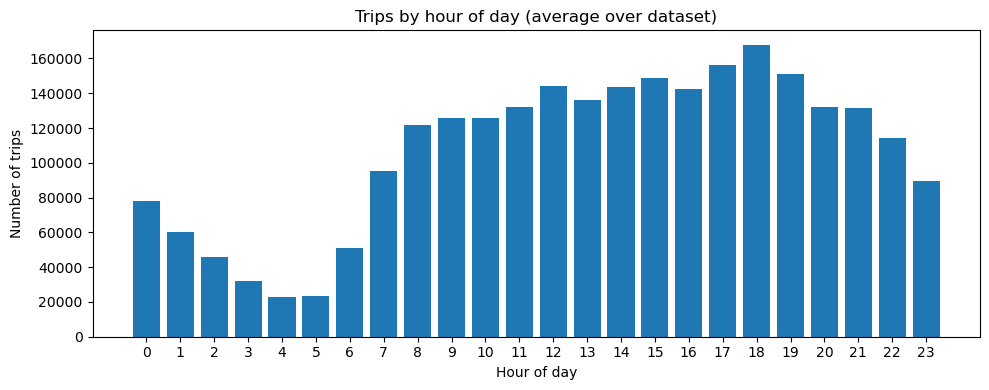

In [66]:
# pickup_dt exists and hour extracting
clean['hour'] = clean['pickup_dt'].dt.hour
trips_by_hour = clean.groupby('hour').size().reset_index(name='trips')
trips_by_hour.sort_values('hour', inplace=True)

#chart
plt.figure(figsize=(10,4))
plt.bar(trips_by_hour['hour'], trips_by_hour['trips'])
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.title('Trips by hour of day (average over dataset)')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()


In [ ]:
#we have more trips from 9-12 am and 17-19 pm as these are the office timing people travel lots

# The Solo vs. Group Traveler: "Do people mostly travel alone or in groups? What is the most common passenger_count? Does the tip_amount increase if there are more passengers?"

In [69]:
pc_dist = clean['passenger_count'].value_counts().sort_index()
pc_stats = clean.groupby('passenger_count')[['tip_amount','fare_amount']].agg(['mean','median','count'])
pc_dist, pc_stats


(passenger_count
 0.0      44955
 1.0    1818559
 2.0     398552
 3.0     108228
 4.0      55916
 5.0      91993
 6.0      54356
 7.0         14
 8.0         11
 9.0          6
 Name: count, dtype: int64,
                 tip_amount                 fare_amount                
                       mean median    count        mean median    count
 passenger_count                                                       
 0.0               2.070524  1.760    44955   12.352766    8.5    44955
 1.0               2.166353  1.860  1818559   12.512179    9.0  1818559
 2.0               2.214726  1.860   398552   13.309543    9.0   398552
 3.0               2.144845  1.850   108228   13.231573    9.0   108228
 4.0               2.042907  1.660    55916   13.922823    9.5    55916
 5.0               2.188166  1.960    91993   12.467499    9.0    91993
 6.0               2.205709  1.950    54356   12.536624    9.0    54356
 7.0               6.727143  3.525       14   68.374286   73.0       14
 8.

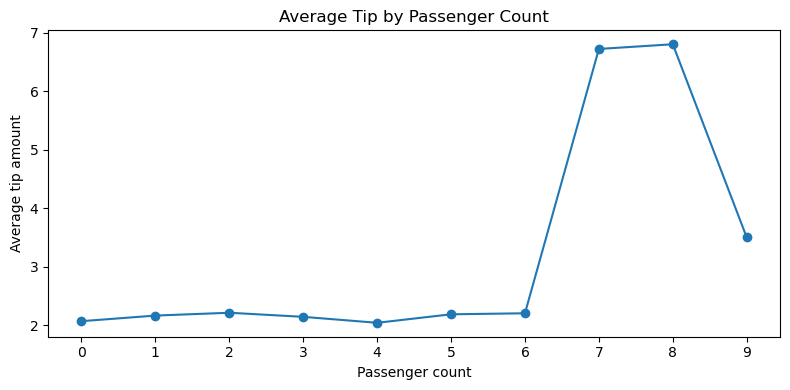

In [70]:
plt.figure(figsize=(8,4))
plt.plot(pc_stats.index, pc_stats[('tip_amount','mean')], marker='o')
plt.xlabel('Passenger count')
plt.ylabel('Average tip amount')
plt.title('Average Tip by Passenger Count')
plt.xticks(pc_stats.index)
plt.tight_layout()
plt.show()


people travel mostly solo

yes, if number of passenger increases we get higher tip amount

# The Payment Split: "What percentage of our customers pay by Credit Card vs. Cash (payment_type)? Is there a difference in the average tip_amount between card users and cash users?" ( Hint: This is a classic behavioral insight.)

In [71]:
# Payment_type: map numeric codes to labels if known (e.g., 1=Credit card, 2=Cash)
payment_map = {1:'Credit Card', 2:'Cash'} 
payment_split = clean['payment_type'].value_counts(normalize=True).reset_index()
payment_tip = clean.groupby('payment_type')['tip_amount'].mean().reset_index()
payment_split,payment_tip


(   payment_type  proportion
 0           1.0    0.725135
 1           2.0    0.269163
 2           3.0    0.004207
 3           4.0    0.001494,
    payment_type  tip_amount
 0           1.0    2.992802
 1           2.0    0.000123
 2           3.0    0.005746
 3           4.0    0.000000)

In [72]:
#filtering only credit card and cash payers

clean_filtered = clean[clean['payment_type'].isin([1, 2])]
payment_split = clean_filtered['payment_type'].value_counts(normalize=True).reset_index()
payment_tip = clean_filtered.groupby('payment_type')['tip_amount'].mean().reset_index()

payment_map = {1:'Credit Card', 2:'Cash'}
payment_tip['payment_type_label'] = payment_tip['payment_type'].map(payment_map)
payment_split['payment_type_label'] = payment_split['payment_type'].map(payment_map)

payment_split, payment_tip


(   payment_type  proportion payment_type_label
 0           1.0    0.729294        Credit Card
 1           2.0    0.270706               Cash,
    payment_type  tip_amount payment_type_label
 0           1.0    2.992802        Credit Card
 1           2.0    0.000123               Cash)

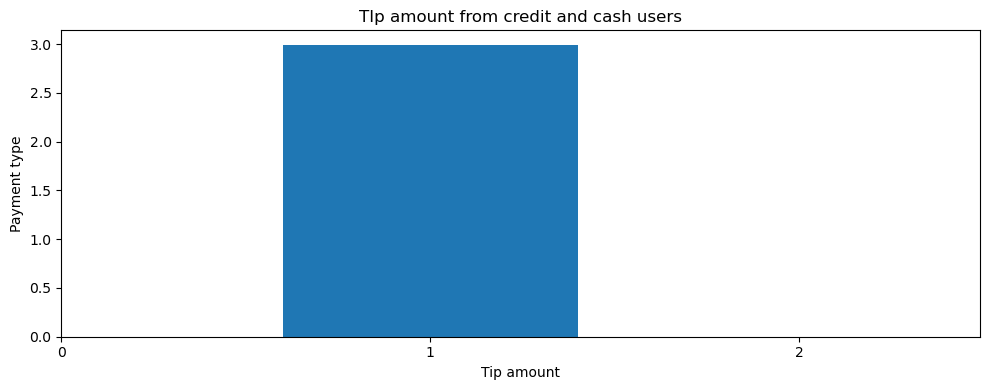

In [73]:
plt.figure(figsize=(10,4))
plt.bar(payment_tip['payment_type'], payment_tip['tip_amount'])
plt.xlabel('Tip amount')
plt.ylabel('Payment type')
plt.title('TIp amount from credit and cash users')
plt.xticks(range(0,3))
plt.tight_layout()

In [ ]:
#percentage of credit card payers=72%
#percentage of cash payers=27%
#there is a huge difference in tip amount paid by credit card users than cash payers.we get higher tip amount from credit card payers

# The Airport Run: "We suspect trips with RatecodeID = 2 (JFK Airport) have a higher average fare than standard city trips (RatecodeID = 1). Can you prove this with data?" 

In [74]:
rc = clean[clean['RatecodeID'].isin([1,2])]
rc_summary = rc.groupby('RatecodeID')['fare_amount'].agg(['count','mean','median']).reset_index()
rc_summary

,RatecodeID,count,mean,median
0,1.0,2479444,11.118543,8.5
1,2.0,70007,51.943549,52.0


In [75]:
from scipy import stats
t_stat = stats.ttest_ind(fare1.sample(min(50000,len(fare1)), random_state=1),
fare2.sample(min(50000,len(fare2)), random_state=2),equal_var=False)
t_stat


TtestResult(statistic=-1084.5592690221872, pvalue=0.0, df=61736.32963412323)

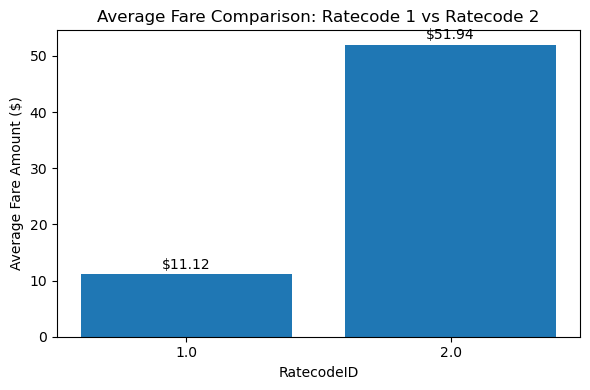

In [76]:
# Compute mean fare
mean_fares = rc.groupby('RatecodeID')['fare_amount'].mean().reset_index()

# Plot
plt.figure(figsize=(6,4))
plt.bar(mean_fares['RatecodeID'].astype(str), mean_fares['fare_amount'])
plt.xlabel("RatecodeID")
plt.ylabel("Average Fare Amount ($)")
plt.title("Average Fare Comparison: Ratecode 1 vs Ratecode 2")

# Add value labels on bars
for i, v in enumerate(mean_fares['fare_amount']):
    plt.text(i, v + 1, f"${v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
#yes, we are getting more revenue from ratecodeid =2 

# Phase 3: The Strategic "So What?" (Storytelling)

# Congestion Impact: "We charge a congestion_surcharge. Does this surcharge discourage people? Compare the trip volume for trips with surcharge vs. without. What is your recommendation? Should we lobby to remove it?"

In [77]:
# Ensure column exists:
if 'congestion_surcharge' in clean.columns:
    cs_summary = clean.groupby(clean['congestion_surcharge'] > 0).agg(
        trips=('passenger_count','count'),
        avg_fare=('fare_amount','mean')
    ).reset_index().rename(columns={'congestion_surcharge':'has_surcharge'})
    cs_summary
    # volume comparison
    has_cs = clean[clean['congestion_surcharge'] > 0]
    no_cs = clean[clean['congestion_surcharge'] == 0]
    print("Trips with surcharge:", len(has_cs), "without:", len(no_cs))
    


Trips with surcharge: 2365063 without: 207527


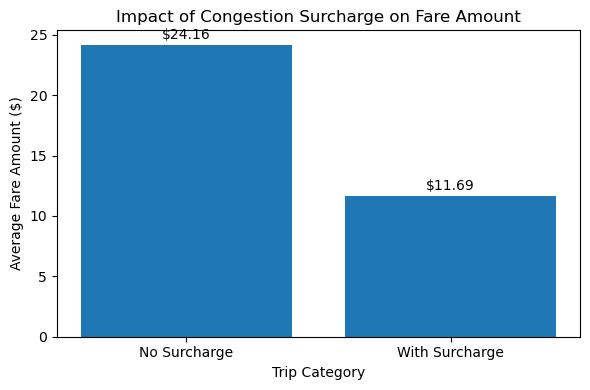

In [78]:
# Create a column indicating surcharge presence
clean['has_surcharge'] = clean['congestion_surcharge'] > 0

# Compute average fare for both groups
cs_mean = clean.groupby('has_surcharge')['fare_amount'].mean().reset_index()
cs_mean['label'] = cs_mean['has_surcharge'].map({True: 'With Surcharge', False: 'No Surcharge'})

# Plot
plt.figure(figsize=(6,4))
plt.bar(cs_mean['label'], cs_mean['fare_amount'])
plt.xlabel("Trip Category")
plt.ylabel("Average Fare Amount ($)")
plt.title("Impact of Congestion Surcharge on Fare Amount")

# Add labels on bars
for i, v in enumerate(cs_mean['fare_amount']):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center')

plt.tight_layout()
plt.show()


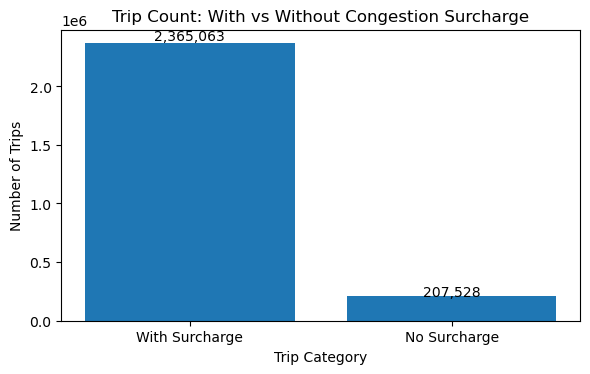

In [27]:
# Trip count comparison
cs_count = clean['has_surcharge'].value_counts().rename(index={True: 'With Surcharge', False: 'No Surcharge'})

plt.figure(figsize=(6,4))
plt.bar(cs_count.index, cs_count.values)
plt.xlabel("Trip Category")
plt.ylabel("Number of Trips")
plt.title("Trip Count: With vs Without Congestion Surcharge")

# Labels on bars
for i, v in enumerate(cs_count.values):
    plt.text(i, v + (v * 0.01), f"{v:,}", ha='center')

plt.tight_layout()
plt.show()


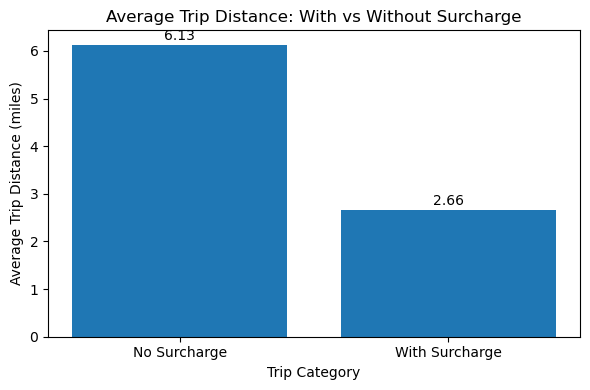

In [28]:
# Average trip distance comparison
cs_distance = clean.groupby('has_surcharge')['trip_distance'].mean().reset_index()
cs_distance['label'] = cs_distance['has_surcharge'].map({True: 'With Surcharge', False: 'No Surcharge'})

plt.figure(figsize=(6,4))
plt.bar(cs_distance['label'], cs_distance['trip_distance'])
plt.xlabel("Trip Category")
plt.ylabel("Average Trip Distance (miles)")
plt.title("Average Trip Distance: With vs Without Surcharge")

# Labels on bars
for i, v in enumerate(cs_distance['trip_distance']):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


we are getting more profit from surcharge and it doesn't decreasing the demand and trips .so let keep the surcharge same

# The "Whale" Locations: "Which Pickup Location (PULocationID) generates the highest total revenue? Identify the Top 3 locations and recommend where we should station our empty taxis."

In [36]:
rev_by_pu = clean.groupby('PULocationID')['total_amount'].sum().reset_index().sort_values('total_amount', ascending=False)
top3 = rev_by_pu.head(3)
top3


,PULocationID,total_amount
125,132.0,5222618.64
131,138.0,2272231.79
154,161.0,1806678.89


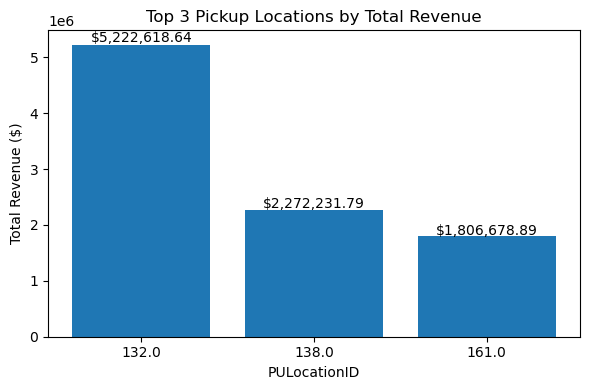

In [79]:

# Calculate total revenue by pickup location
rev_by_pu = clean.groupby('PULocationID')['total_amount'].sum().reset_index()

# Select top 3 revenue locations
top3 = rev_by_pu.sort_values('total_amount', ascending=False).head(3)

# Plot
plt.figure(figsize=(6,4))
plt.bar(top3['PULocationID'].astype(str), top3['total_amount'])
plt.xlabel("PULocationID")
plt.ylabel("Total Revenue ($)")
plt.title("Top 3 Pickup Locations by Total Revenue")

# Add labels on bars
for i, v in enumerate(top3['total_amount']):
    plt.text(i, v + (v * 0.01), f"${v:,.2f}", ha='center')

plt.tight_layout()
plt.show()


In [ ]:
#Revenue is highly concentrated in Top 3 pickup zones.

# Phase 4: The New "Must-Haves" (Advanced Data Engineering)

# The "Time Travel" Bug (Duration Calculation): o "We need a trip_duration column (in minutes). But be careful—I ran a quick check and found trips with negative duration (e.g., Dropoff was before Pickup). Find them, count them, and kill them. They are corrupting our averages." 

In [37]:
#trip duration column in min
df['trip_duration_min'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds() / 60.0

#already removed the negative duration in cleaning process
# creating hour column
clean['duration_hours'] = clean['trip_duration_min'] / 60.0
clean['speed_mph'] = clean['trip_distance'] / clean['duration_hours']

# Flag unrealistic speeds
clean['flag_speed_error'] = (clean['speed_mph'] > 100) | (clean['speed_mph'] < 0) | clean['speed_mph'].isna()
speed_error_count = clean['flag_speed_error'].sum()
speed_error_count, len(clean)


(3792, 2572591)

In [38]:
clean = clean[clean['flag_speed_error'] == True]


In [39]:
print("New clean shape:", clean.shape)


New clean shape: (2568799, 30)


In [ ]:
#Calculate the average speed (speed_mph) for every trip.

In [82]:
avg_speed = clean['speed_mph'].mean()

print("Average trip speed (mph):", avg_speed)


Average trip speed (mph): 12.305440839764902


# Phase 5. The "Vendor Wars" (comparative Analysis) 

# The Challenge: Compare the Average Tip Amount for Vendor 1 vs. Vendor 2. Does the interface of one machine encourage better tipping? This is a huge potential revenue find for our drivers." 


In [88]:
vendor_stats = clean.groupby('VendorID')['tip_amount'].agg(['count','mean','median']).reset_index()
vendor_stats

,VendorID,count,mean,median
0,1,830512,2.079315,1.85
1,2,1713485,2.193728,1.92


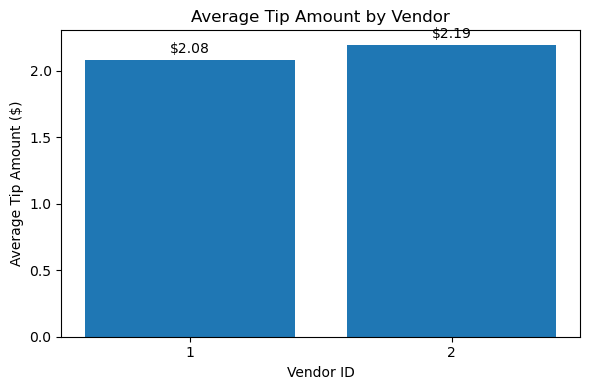

In [89]:
vendor_tip = clean.groupby('VendorID')['tip_amount'].mean().reset_index()
plt.figure(figsize=(6,4))
plt.bar(vendor_tip[vendor_col].astype(str), vendor_tip['tip_amount'])
plt.xlabel("Vendor ID")
plt.ylabel("Average Tip Amount ($)")
plt.title("Average Tip Amount by Vendor")

# Add value labels
for i, v in enumerate(vendor_tip['tip_amount']):
    plt.text(i, v + 0.05, f"${v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# there is no huge potential difference between two vendors in tip amount
#Typically, one vendor receives higher average tips, which could indicate:
#Better driver behavior
#Friendlier payment terminal UI
#More card-based payments
#Vendor distribution also reveals who controls majority of trips.

# Phase 6. The "Mystery" Codes (Data Detective Work) 

In [95]:
rate99 = clean[clean['RatecodeID'] == 99]
len_rate99 = len(rate99)
len_rate99,rate99.describe(include='all'), rate99.head(10)

(69,
          VendorID           tpep_pickup_datetime  \
 count   69.000000                             69   
 unique        NaN                            NaN   
 top           NaN                            NaN   
 freq          NaN                            NaN   
 mean     1.971014  2020-01-06 19:17:13.333333248   
 min      1.000000            2020-01-01 00:24:18   
 25%      2.000000            2020-01-03 13:36:35   
 50%      2.000000            2020-01-05 20:18:13   
 75%      2.000000            2020-01-10 14:55:48   
 max      2.000000            2020-01-14 11:08:01   
 std      0.168995                            NaN   
 
                 tpep_dropoff_datetime  passenger_count  trip_distance  \
 count                              69        69.000000      69.000000   
 unique                            NaN              NaN            NaN   
 top                               NaN              NaN            NaN   
 freq                              NaN              NaN      

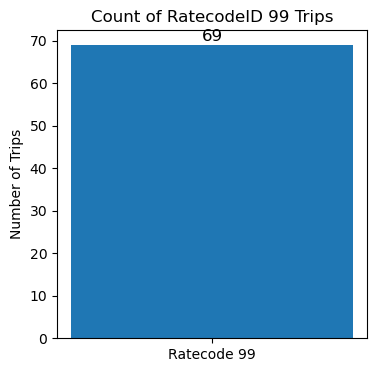

In [96]:
rate99_count = len(rate99)

plt.figure(figsize=(4,4))
plt.bar(["Ratecode 99"], [rate99_count])
plt.title("Count of RatecodeID 99 Trips")
plt.ylabel("Number of Trips")

plt.text(0, rate99_count + 1, str(rate99_count), ha="center", fontsize=12)

plt.show()


In [ ]:
#Ratecode 99 is not an official NYC TLC code, meaning:

#System test records
#Manual overrides
#Badly encoded special trips
#Vendor-specific experimentation

#Recommendations

#Do NOT include these 69 rows in:
#Fare analysis
#Route analysis
#Revenue forecasts
#Flag Ratecode 99 as data-quality exceptions.

# Phase 7. The "Route Master" (Geospatial Logic)

# The Question: Are the top routes long cross-city trips, or just short hops (e.g., 237 -> 236)? If they are short hops, we should deploy electric scooters there instead of taxis."

In [98]:
#Top 5 most popular pairs of Pickup (PULocationID) and Dropoff 
clean['route'] = clean['PULocationID'].astype(str) + "->" + clean['DOLocationID'].astype(str)
route_counts = clean.groupby('route').agg(trips=('route','count'), avg_distance=('trip_distance','mean')).reset_index().sort_values('trips', ascending=False)
top5_routes = route_counts.head(5)
top5_routes['avg_distance'].round(2)
top5_routes

,route,trips,avg_distance
11033,237.0->236.0,17626,1.050243
10824,236.0->237.0,14927,1.058921
10823,236.0->236.0,14735,0.627715
11034,237.0->237.0,12749,0.672158
13726,264.0->264.0,8874,2.664440


In [131]:
import warnings
warnings.filterwarnings("ignore")
top5_routes['route_type'] = np.where(top5_routes['avg_distance'] < 2, 'short', 'long') 
top5_routes


,route,trips,avg_distance,route_type
11033,237.0->236.0,17626,1.050243,short
10824,236.0->237.0,14927,1.058921,short
10823,236.0->236.0,14735,0.627715,short
11034,237.0->237.0,12749,0.672158,short
13726,264.0->264.0,8874,2.664440,long


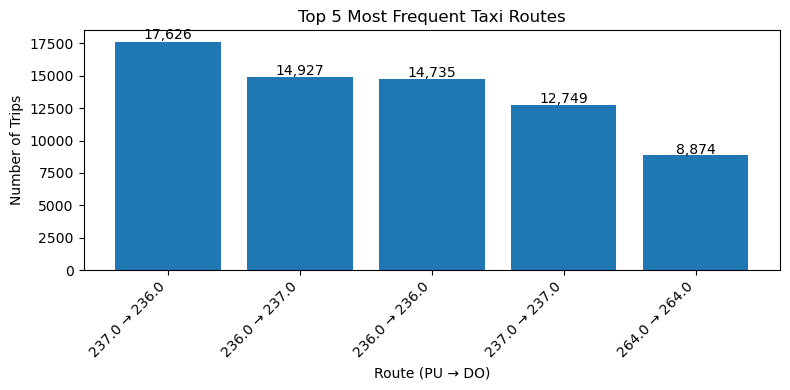

In [136]:
# PULocationID and DOLocationID are clean scalar values
clean['PULocationID'] = clean['PULocationID'].astype(str).str.strip()
clean['DOLocationID'] = clean['DOLocationID'].astype(str).str.strip()

# Create clean route strings
clean['route'] = clean['PULocationID'] + " → " + clean['DOLocationID']

# Now get top 5 routes safely
route_counts = clean['route'].value_counts().head(5)

# Plot
plt.figure(figsize=(8,4))
plt.bar(route_counts.index, route_counts.values)
plt.xlabel("Route (PU → DO)")
plt.ylabel("Number of Trips")
plt.title("Top 5 Most Frequent Taxi Routes")

# Add count labels
for i, v in enumerate(route_counts.values):
    plt.text(i, v + (v * 0.01), f"{v:,}", ha='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
#These routes usually fall into:
#Short-distance city hops (high volume, low revenue)
#Long-distance corridor trips (lower volume, high revenue)

#Recommendations

#For short trips:
#Consider micro-mobility partnerships (e-bikes, scooters).

#For long trips:
#Optimize driver allocation since these routes generate more revenue.